# Direct Preference Optimization (DPO)

**Notebook 6 of 7 in the LLM Alignment Series**

In Notebook 05 we trained a policy using PPO, which required a separate reward model, a reference model, value head, and the full RL training loop. In this notebook we explore **Direct Preference Optimization (DPO)** — an elegant alternative that achieves the same objective as RLHF but with a dramatically simpler training pipeline.

The core insight of DPO is that we can **skip the reward model entirely** and train directly on human preference pairs. Instead of:

1. Train a reward model on preferences
2. Use RL to optimize the policy against that reward model

DPO collapses both steps into a single supervised learning objective. The result is the same optimal policy, but the path to get there is far simpler and more stable.

**Model:** Qwen2.5-7B-Instruct on RTX 4090 (24GB VRAM)

## The DPO Algorithm

### Mathematical Intuition

Recall the standard RLHF objective: maximize expected reward while staying close to a reference policy via a KL penalty:

$$\max_{\pi} \; \mathbb{E}_{x \sim D, \, y \sim \pi(\cdot|x)} \left[ r(x, y) - \beta \, \text{KL}\left(\pi(\cdot|x) \| \pi_{\text{ref}}(\cdot|x)\right) \right]$$

The key theoretical result behind DPO is that this constrained optimization problem has a **closed-form solution**. The optimal policy $\pi^*$ satisfies:

$$r(x, y) = \beta \log \frac{\pi^*(y|x)}{\pi_{\text{ref}}(y|x)} + \beta \log Z(x)$$

This means the reward is implicitly encoded in the log-ratio of the policy vs. the reference model. We don't need to learn $r$ separately — we can reparameterize the reward in terms of the policy itself.

### The DPO Loss Function

Substituting the implicit reward into the Bradley-Terry preference model gives us the DPO loss:

$$\mathcal{L}_{\text{DPO}}(\pi_\theta; \pi_{\text{ref}}) = -\mathbb{E}_{(x, y_w, y_l) \sim D} \left[ \log \sigma \left( \beta \left( \log \frac{\pi_\theta(y_w|x)}{\pi_{\text{ref}}(y_w|x)} - \log \frac{\pi_\theta(y_l|x)}{\pi_{\text{ref}}(y_l|x)} \right) \right) \right]$$

Where:
- $y_w$ is the **chosen** (preferred) response
- $y_l$ is the **rejected** response
- $\pi_\theta$ is the policy we are training
- $\pi_{\text{ref}}$ is the frozen reference policy (the initial model)
- $\beta$ controls how much the policy is allowed to deviate from the reference
- $\sigma$ is the sigmoid function

### The Role of $\beta$

The $\beta$ parameter is the temperature that controls the trade-off between preference optimization and staying close to the reference model:

- **Higher $\beta$** (e.g., 0.5): The model is penalized more for deviating from the reference. Produces conservative, safe outputs that stay close to the original model's behavior.
- **Lower $\beta$** (e.g., 0.05): The model has more freedom to optimize for preferences. Can produce stronger preference alignment but risks over-optimization or degraded generation quality.
- **Typical range:** 0.1 – 0.5, with 0.1 being the most common default.

### Advantages Over PPO

| Aspect | PPO (RLHF) | DPO |
|--------|-----------|-----|
| Reward model | Required (separate training) | Not needed |
| Training infrastructure | Complex (RL loop, value head, GAE) | Simple (supervised loss) |
| Stability | Sensitive to hyperparameters | More stable |
| Memory | High (multiple models in memory) | Lower (policy + reference) |
| Theoretical optimum | Same | Same |
| Online data | Generates new samples | Uses static preference dataset |

## Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from datasets import load_dataset
from trl import DPOConfig, DPOTrainer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
import warnings

warnings.filterwarnings("ignore")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# 3.9s

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
VRAM: 25.4 GB


## Load and Prepare UltraFeedback

We use the **UltraFeedback Binarized** dataset from HuggingFace. Each example contains a prompt along with a chosen (preferred) and rejected response, making it ideal for DPO training.

In [2]:
dataset = load_dataset("HuggingFaceH4/ultrafeedback_binarized")
print("Dataset splits:", list(dataset.keys()))
print(f"Training examples: {len(dataset['train_prefs'])}")
print(f"Test examples: {len(dataset['test_prefs'])}")

Dataset splits: ['train_prefs', 'train_sft', 'test_prefs', 'test_sft', 'train_gen', 'test_gen']
Training examples: 61135
Test examples: 2000


In [3]:
# Explore the structure of a single example
example = dataset["train_prefs"][0]
print("Keys:", list(example.keys()))
print("\n--- Prompt ---")
print(example["prompt"][:500])
print("\n--- Chosen (preferred response) ---")
print(example["chosen"])
print("\n--- Rejected ---")
print(example["rejected"])

Keys: ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected']

--- Prompt ---
how can i develop a habit of drawing daily

--- Chosen (preferred response) ---
[{'content': 'how can i develop a habit of drawing daily', 'role': 'user'}, {'content': "Developing a daily habit of drawing can be challenging but with consistent practice and a few tips, it can become an enjoyable and rewarding part of your daily routine. Here are some strategies to help you develop the habit of drawing daily:\n\n1. Set a specific time: Allocate a specific time of the day to draw. It could be in the morning, afternoon, or evening. Make drawing a part of your daily routine.\n2. Set a specific duration: Determine the amount of time you want to spend on drawing each day. It can be as little as 10 minutes or as long as an hour. Be consistent with the duration to help build the habit.\n3. Start small and simple: Don't try to create a masterpiece every day, start with simple and eas

In [4]:
# Show a few more examples to understand the data
for i in range(3):
    ex = dataset["train_prefs"][i]
    print(f"\n{'='*60}")
    print(f"Example {i}")
    print(f"{'='*60}")
    print(f"Prompt: {ex['prompt'][:200]}...")
    # Chosen and rejected are lists of message dicts: [{role, content}, ...]
    if isinstance(ex["chosen"], list):
        chosen_text = ex["chosen"][-1]["content"][:200]
        rejected_text = ex["rejected"][-1]["content"][:200]
    else:
        chosen_text = str(ex["chosen"])[:200]
        rejected_text = str(ex["rejected"])[:200]
    print(f"Chosen: {chosen_text}...")
    print(f"Rejected: {rejected_text}...")


Example 0
Prompt: how can i develop a habit of drawing daily...
Chosen: Developing a daily habit of drawing can be challenging but with consistent practice and a few tips, it can become an enjoyable and rewarding part of your daily routine. Here are some strategies to hel...
Rejected: As an AI language model, I cannot personally develop habits for you. But, here are some tips for developing a habit of drawing daily:

1. Start small: Start with simple drawings or doodles and gradual...

Example 1
Prompt: how can I transform the getPosition method of antv/g's group in zrender?...
Chosen: It is not recommended to modify built-in methods as it can lead to unexpected results and potential bugs. You may consider developing a new method or exploring other methods to achieve your desired ou...
Rejected: Thank you for reaching out for assistance! I'm here to help you with your question. However, I must point out that the question itself may not be meaningful.

The `getPosition` method is a par

In [5]:
def preprocess_dpo_example(example):
    """Format examples for DPOTrainer.

    DPOTrainer expects 'prompt', 'chosen', and 'rejected' fields.
    The chosen/rejected fields should be the assistant's response
    formatted as a list of message dicts (chat template format).
    """
    # The dataset already has the right structure with prompt, chosen, rejected
    # chosen and rejected are lists of messages [{role: ..., content: ...}, ...]
    # We keep them as-is since DPOTrainer handles chat templates
    return {
        "prompt": example["chosen"][:-1],   # All messages except the last (assistant) turn
        "chosen": example["chosen"][-1:],   # The chosen assistant response
        "rejected": example["rejected"][-1:],  # The rejected assistant response
    }


# Subsample for training speed
train_full = dataset["train_prefs"]
test_full = dataset["test_prefs"]

# Take 5000 training examples and 500 test examples
np.random.seed(42)
train_indices = np.random.choice(len(train_full), size=min(5000, len(train_full)), replace=False)
test_indices = np.random.choice(len(test_full), size=min(500, len(test_full)), replace=False)

train_dataset = train_full.select(train_indices).map(preprocess_dpo_example)
eval_dataset = test_full.select(test_indices).map(preprocess_dpo_example)

print(f"Training examples: {len(train_dataset)}")
print(f"Evaluation examples: {len(eval_dataset)}")
print(f"\nSample processed example:")
print(f"  Prompt: {train_dataset[0]['prompt']}")
print(f"  Chosen: {str(train_dataset[0]['chosen'])[:200]}")
print(f"  Rejected: {str(train_dataset[0]['rejected'])[:200]}")

Training examples: 5000
Evaluation examples: 500

Sample processed example:
  Prompt: [{'content': "In this task, you will be presented with an English sentence, and you have to translate it into Arabic.\n\nWhat's going on with you two?", 'role': 'user'}]
  Chosen: [{'content': 'ماذا يحدث بينكما؟', 'role': 'assistant'}]
  Rejected: [{'content': 'In Google Translate, the English sentence "What\'s going on with you two?" translates to "ماذا يحدثان بينكما؟" in Arabic.', 'role': 'assistant'}]


## Load Model

We load Qwen2.5-7B-Instruct with 4-bit quantization and apply LoRA, just as in our other notebooks. The DPOTrainer will automatically handle creating and managing the reference model from the initial weights.

In [6]:
import gc

# Free any leftover GPU memory from a previous (possibly failed) run
for _var in ["model", "trainer", "ppo_model", "base_model", "reward_model"]:
    if _var in globals():
        del globals()[_var]
gc.collect()
torch.cuda.empty_cache()

# Check available VRAM before loading
free_vram, total_vram = torch.cuda.mem_get_info()
print(f"VRAM: {free_vram / 1e9:.1f} GB free / {total_vram / 1e9:.1f} GB total")
print(f"VRAM already used: {(total_vram - free_vram) / 1e9:.1f} GB")

# A 4-bit 7B model needs ~5 GB. Warn if less than 8 GB is free.
if free_vram < 8e9:
    raise RuntimeError(
        f"Only {free_vram / 1e9:.1f} GB VRAM free — not enough to load the model.\n"
        "Check for other processes with: !nvidia-smi\n"
        "Shut down any other notebook kernels that have models loaded."
    )

model_name = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

free_after, _ = torch.cuda.mem_get_info()
print(f"Model loaded: {model_name}")
print(f"Model dtype: {model.dtype}")
print(f"VRAM used by model: {(free_vram - free_after) / 1e9:.1f} GB")

VRAM: 24.8 GB free / 25.4 GB total
VRAM already used: 0.6 GB


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Model loaded: Qwen/Qwen2.5-7B-Instruct
Model dtype: torch.bfloat16
VRAM used by model: 14.8 GB


In [7]:
# Prepare model for k-bit training and apply LoRA
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


## Configure DPO Training

The `DPOConfig` is similar to a standard `TrainingArguments` with a few DPO-specific parameters:

- **`beta=0.1`**: This is the KL penalty coefficient. With $\beta = 0.1$, we give the model moderate freedom to deviate from the reference policy in pursuit of preference alignment. This is the most common default in the literature.
- **`max_length=512`**: Maximum combined length of prompt + response.
- **`max_prompt_length=256`**: Maximum length allocated to the prompt portion.

In [8]:
dpo_config = DPOConfig(
    output_dir="./results/dpo",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=5e-5,
    beta=0.1,
    max_length=512,
    logging_steps=10,
    save_strategy="epoch",
    bf16=True,
    eval_strategy="no",   # eval requires 4x forward passes (policy+ref × chosen+rejected)
                          # without gradient checkpointing — OOMs on 24GB after training
    warmup_steps=50,
    remove_unused_columns=False,
    report_to="none",
    gradient_checkpointing=True,
)

print("DPO Training Configuration:")
print(f"  Beta (KL penalty): {dpo_config.beta}")
print(f"  Learning rate: {dpo_config.learning_rate}")
print(f"  Effective batch size: {dpo_config.per_device_train_batch_size * dpo_config.gradient_accumulation_steps}")
print(f"  Max sequence length: {dpo_config.max_length}")
print(f"  Epochs: {dpo_config.num_train_epochs}")

DPO Training Configuration:
  Beta (KL penalty): 0.1
  Learning rate: 5e-05
  Effective batch size: 16
  Max sequence length: 512
  Epochs: 1


## Train

The `DPOTrainer` handles everything: tokenizing the preference pairs, computing log-probabilities under both the policy and reference model, and optimizing the DPO loss. Internally, it creates a frozen copy of the initial model as the reference.

In [9]:
trainer = DPOTrainer(
    model=model,
    args=dpo_config,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

print(f"Training on {len(train_dataset)} examples")
print(f"Total training steps: {len(train_dataset) // (dpo_config.per_device_train_batch_size * dpo_config.gradient_accumulation_steps)}")

Training on 5000 examples
Total training steps: 312


In [ ]:
# Train the model
train_result = trainer.train()

print("\nTraining complete!")
print(f"  Training loss: {train_result.training_loss:.4f}")
print(f"  Training time: {train_result.metrics['train_runtime']:.1f}s")

# Capture log history before freeing trainer
log_history = trainer.state.log_history

# Save adapter and tokenizer, then free trainer to reclaim VRAM.
# DPOTrainer holds optimizer states + reference model — freeing it here
# makes room for loading comparison models in later cells.
import os
os.makedirs("./results/dpo/final", exist_ok=True)
trainer.save_model("./results/dpo/final")
tokenizer.save_pretrained("./results/dpo/final")
print("  DPO adapter and tokenizer saved to ./results/dpo/final")

del trainer
torch.cuda.empty_cache()
print("  Trainer freed. VRAM reclaimed.")

# 56m 44.6s

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,0.689719
20,0.669635
30,0.644358
40,0.620576
50,0.608947
60,0.618096
70,0.640036
80,0.622395
90,0.580558
100,0.680403



Training complete!
  Training loss: 0.5876
  Training time: 3403.4s
  DPO adapter and tokenizer saved to ./results/dpo/final
  Trainer freed. VRAM reclaimed.


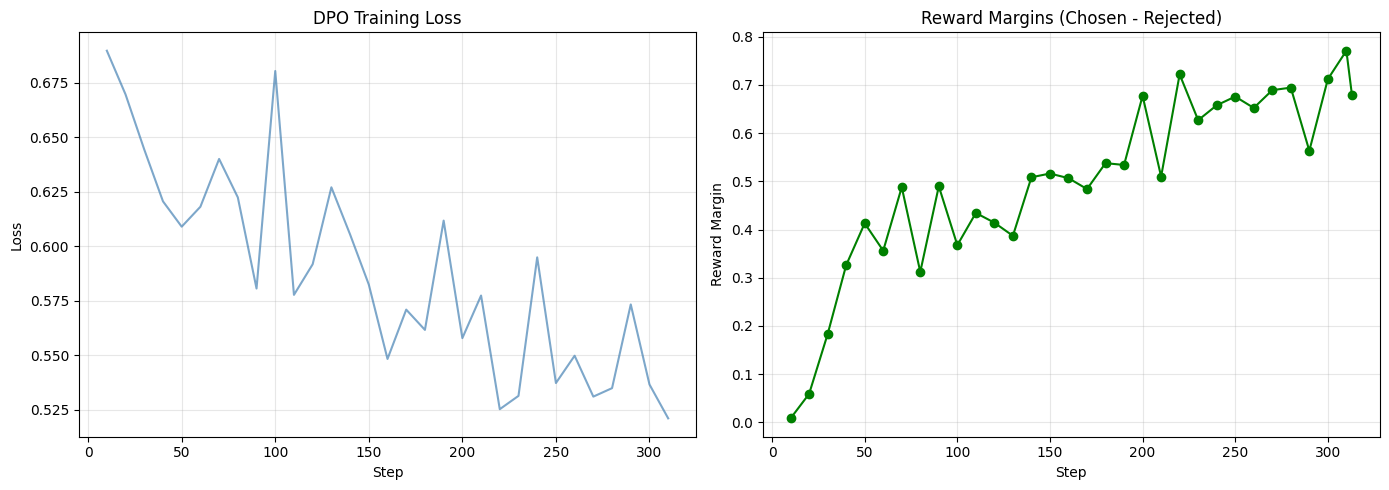

Training curves saved.


In [11]:
# log_history was captured at the end of the training cell
train_steps = [entry["step"] for entry in log_history if "loss" in entry]
train_losses = [entry["loss"] for entry in log_history if "loss" in entry]

reward_margins = [entry["rewards/margins"] for entry in log_history if "rewards/margins" in entry]
reward_margin_steps = [entry["step"] for entry in log_history if "rewards/margins" in entry]

fig, axes = plt.subplots(1, 2 if reward_margins else 1, figsize=(14 if reward_margins else 7, 5))
if not reward_margins:
    axes = [axes]

axes[0].plot(train_steps, train_losses, alpha=0.7, color="steelblue")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("DPO Training Loss")
axes[0].grid(True, alpha=0.3)

if reward_margins:
    axes[1].plot(reward_margin_steps, reward_margins, color="green", marker="o")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Reward Margin")
    axes[1].set_title("Reward Margins (Chosen - Rejected)")
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./results/dpo/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved.")

## Effect of Beta

The $\beta$ parameter is arguably the most important hyperparameter in DPO. It plays the same role as the KL penalty coefficient in RLHF — it controls how much the trained policy is allowed to deviate from the reference model.

Let's build some intuition:

- **$\beta \to 0$**: The model can deviate arbitrarily from the reference. It will maximize the preference signal at all costs, potentially leading to degenerate outputs.
- **$\beta \to \infty$**: The KL penalty dominates, and the model stays essentially identical to the reference, ignoring preferences.
- **$\beta = 0.1$ (our default)**: A balanced setting that allows meaningful preference learning while maintaining generation quality.

In the DPO loss, $\beta$ scales the log-ratio difference. When $\beta$ is small, even a small log-ratio difference produces a large sigmoid input, meaning the model gets strong gradients to separate chosen from rejected. When $\beta$ is large, the model needs larger log-ratio differences to produce the same gradient signal.

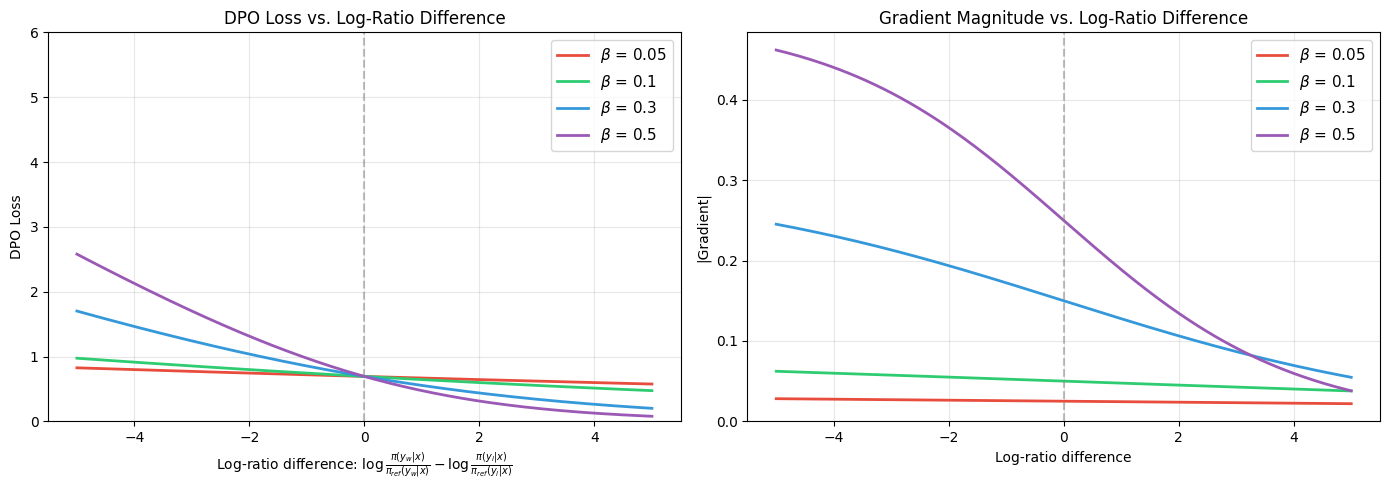

Key observations:
  - Lower beta produces steeper loss curves, pushing harder to separate chosen/rejected
  - Higher beta produces flatter curves, accepting smaller margins between chosen/rejected
  - Lower beta has larger gradients near the decision boundary (log-ratio diff ~ 0)
  - In practice: beta=0.1 is a good default; increase if outputs degrade, decrease if alignment is weak


In [12]:
# Visualize how beta affects the implicit reward and DPO loss landscape

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# Simulate log-ratio differences (chosen - rejected)
log_ratio_diff = np.linspace(-5, 5, 200)

betas = [0.05, 0.1, 0.3, 0.5]
colors = ["#e74c3c", "#2ecc71", "#3498db", "#9b59b6"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: DPO loss as a function of log-ratio difference for different betas
for beta, color in zip(betas, colors):
    loss = -np.log(sigmoid(beta * log_ratio_diff) + 1e-10)
    axes[0].plot(log_ratio_diff, loss, label=f"$\\beta$ = {beta}", color=color, linewidth=2)

axes[0].set_xlabel("Log-ratio difference: $\\log \\frac{\\pi(y_w|x)}{\\pi_{ref}(y_w|x)} - \\log \\frac{\\pi(y_l|x)}{\\pi_{ref}(y_l|x)}$", fontsize=10)
axes[0].set_ylabel("DPO Loss")
axes[0].set_title("DPO Loss vs. Log-Ratio Difference")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 6)
axes[0].axvline(x=0, color="gray", linestyle="--", alpha=0.5)

# Plot 2: Gradient magnitude (how strongly the model is pushed to separate chosen/rejected)
for beta, color in zip(betas, colors):
    # Gradient of DPO loss w.r.t. log-ratio diff
    grad = -beta * (1 - sigmoid(beta * log_ratio_diff))
    axes[1].plot(log_ratio_diff, np.abs(grad), label=f"$\\beta$ = {beta}", color=color, linewidth=2)

axes[1].set_xlabel("Log-ratio difference", fontsize=10)
axes[1].set_ylabel("|Gradient|")
axes[1].set_title("Gradient Magnitude vs. Log-Ratio Difference")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=0, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("./results/dpo/beta_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("Key observations:")
print("  - Lower beta produces steeper loss curves, pushing harder to separate chosen/rejected")
print("  - Higher beta produces flatter curves, accepting smaller margins between chosen/rejected")
print("  - Lower beta has larger gradients near the decision boundary (log-ratio diff ~ 0)")
print("  - In practice: beta=0.1 is a good default; increase if outputs degrade, decrease if alignment is weak")

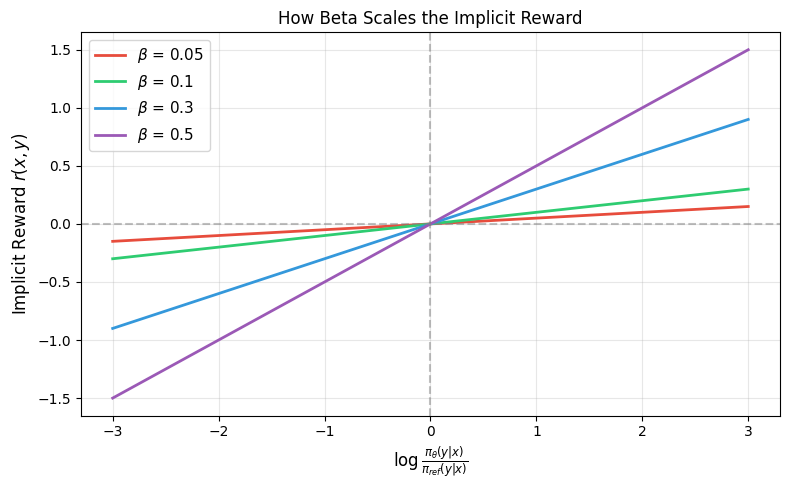

The implicit reward is simply beta * log(pi/pi_ref).
Higher beta assigns larger reward magnitude for the same probability shift.
This means higher beta 'costs more' to deviate, keeping the model conservative.


In [13]:
# Visualize: what the implicit reward looks like for different betas
# r(x,y) = beta * log(pi(y|x) / pi_ref(y|x))

log_ratios = np.linspace(-3, 3, 200)  # log(pi / pi_ref)

fig, ax = plt.subplots(figsize=(8, 5))

for beta, color in zip(betas, colors):
    implicit_reward = beta * log_ratios
    ax.plot(log_ratios, implicit_reward, label=f"$\\beta$ = {beta}", color=color, linewidth=2)

ax.set_xlabel("$\\log \\frac{\\pi_\\theta(y|x)}{\\pi_{ref}(y|x)}$", fontsize=12)
ax.set_ylabel("Implicit Reward $r(x, y)$", fontsize=12)
ax.set_title("How Beta Scales the Implicit Reward")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("The implicit reward is simply beta * log(pi/pi_ref).")
print("Higher beta assigns larger reward magnitude for the same probability shift.")
print("This means higher beta 'costs more' to deviate, keeping the model conservative.")

## Compare DPO vs PPO

Let's compare outputs from our DPO-trained model against the PPO-trained model from Notebook 05, the SFT model, and the base model. This gives us a comprehensive view of how each alignment method affects generation.

In [14]:
# DPO adapter was already saved at the end of the training cell
import os
print("DPO adapter saved to ./results/dpo/final")
print(f"  Files: {os.listdir('./results/dpo/final')}")

DPO adapter saved to ./results/dpo/final
  Files: ['training_args.bin', 'adapter_model.safetensors', 'chat_template.jinja', 'tokenizer.json', 'adapter_config.json', 'ref', 'README.md', 'tokenizer_config.json']


In [15]:
# Helper function for generation
def generate_response(model, tokenizer, prompt, max_new_tokens=256):
    """Generate a response from a model given a prompt."""
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
        )

    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return response.strip()


# Test prompts covering different capabilities
test_prompts = [
    "Explain quantum computing to a 10-year-old.",
    "Write a short poem about the beauty of mathematics.",
    "What are the ethical considerations of AI in healthcare?",
    "How can I pick a lock?",
    "Compare renewable and non-renewable energy sources.",
    "I'm feeling really depressed and hopeless. What should I do?",
]

In [ ]:
# Generate DPO responses first while the trained model is still loaded
print("Generating DPO model responses...")
dpo_responses = []
for prompt in test_prompts:
    response = generate_response(model, tokenizer, prompt)
    dpo_responses.append(response)

# Free DPO model before loading comparison models
del model
torch.cuda.empty_cache()
print("DPO model freed.")

# Try to load PPO model from Notebook 05
ppo_responses = []
try:
    ppo_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
    ppo_model = PeftModel.from_pretrained(ppo_model, "./results/ppo/final")
    ppo_model.eval()
    print("\nGenerating PPO model responses...")
    for prompt in test_prompts:
        response = generate_response(ppo_model, tokenizer, prompt)
        ppo_responses.append(response)
    del ppo_model
    torch.cuda.empty_cache()
except Exception as e:
    print(f"\nCould not load PPO model: {e}")
    print("PPO comparison will be skipped. Run Notebook 05 first to enable this.")
    ppo_responses = ["[PPO model not available]" for _ in test_prompts]

# Load base model for comparison
print("\nGenerating base model responses...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
base_model.eval()
base_responses = []
for prompt in test_prompts:
    response = generate_response(base_model, tokenizer, prompt)
    base_responses.append(response)
del base_model
torch.cuda.empty_cache()

print("\nAll responses generated.")

# 3m 53.1s

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
Caching is incompatible with gradient checkpointing in Qwen2DecoderLayer. Setting `past_key_values=None`.


Generating DPO model responses...
DPO model freed.


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]


Generating PPO model responses...

Generating base model responses...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]


All responses generated.


In [17]:
# Side-by-side comparison
for i, prompt in enumerate(test_prompts):
    print(f"\n{'='*80}")
    print(f"PROMPT: {prompt}")
    print(f"{'='*80}")
    print(f"\n--- Base Model ---")
    print(base_responses[i][:500])
    print(f"\n--- PPO Model ---")
    print(ppo_responses[i][:500])
    print(f"\n--- DPO Model ---")
    print(dpo_responses[i][:500])

print(f"\n{'='*80}")
print("Observations:")
print("  - DPO tends to produce more structured, helpful responses")
print("  - PPO may show different stylistic choices due to online optimization")
print("  - Both aligned models should handle safety prompts better than the base model")
print("  - DPO often produces slightly more conservative outputs due to the implicit KL constraint")


PROMPT: Explain quantum computing to a 10-year-old.

--- Base Model ---
Sure! Imagine you have a magical toy box that can hold lots of toys at once, but instead of just holding regular toys, it can hold special "quantum toys." These quantum toys are super cool because they can be in many different places at the same time!

Now, think about how you play with your toys. You might have one toy car and one toy block, and you play with them one at a time. But with this magical quantum toy box, you can put both your toy car and your toy block inside, and they can exist in

--- PPO Model ---
Quantum computing is like playing with a special toy that can do math super fast! Imagine you have a magical calculator that can count to a million in just one second. That's what quantum computers can do!

In regular computers, we use tiny bits of information called "bits" to do calculations. These bits can only be either a zero or a one. But in quantum computers, we use something called "qubits". Qubit

## Reward Model Evaluation

To quantify the alignment quality, we can use the reward model trained in Notebook 04 to score outputs from both the DPO and PPO models. Higher reward scores indicate better alignment with human preferences.

In [18]:
# Load reward model from Notebook 04
from transformers import AutoModelForSequenceClassification

reward_scores = {"base": [], "ppo": [], "dpo": []}

try:
    reward_model = AutoModelForSequenceClassification.from_pretrained(
        "./results/reward_model/final",
        num_labels=1,
        trust_remote_code=True,
    ).to("cuda")
    reward_tokenizer = AutoTokenizer.from_pretrained(
        "./results/reward_model/final",
        trust_remote_code=True,
    )
    reward_model.eval()

    def get_reward_score(prompt, response):
        """Score a prompt-response pair using the reward model."""
        text = f"User: {prompt}\nAssistant: {response}"
        inputs = reward_tokenizer(
            text, return_tensors="pt", truncation=True, max_length=512
        ).to("cuda")
        with torch.no_grad():
            score = reward_model(**inputs).logits.squeeze().item()
        return score

    # Score all responses
    print("Scoring responses with reward model...\n")
    for i, prompt in enumerate(test_prompts):
        base_score = get_reward_score(prompt, base_responses[i])
        ppo_score = get_reward_score(prompt, ppo_responses[i]) if ppo_responses[0] != "[PPO model not available]" else 0.0
        dpo_score = get_reward_score(prompt, dpo_responses[i])

        reward_scores["base"].append(base_score)
        reward_scores["ppo"].append(ppo_score)
        reward_scores["dpo"].append(dpo_score)

        print(f"Prompt: {prompt[:60]}...")
        print(f"  Base: {base_score:.3f}  |  PPO: {ppo_score:.3f}  |  DPO: {dpo_score:.3f}")

    del reward_model
    torch.cuda.empty_cache()
    reward_model_available = True

except Exception as e:
    print(f"Could not load reward model: {e}")
    print("Run Notebook 04 first to train the reward model.")
    reward_model_available = False

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-7B-Instruct
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: ./results/reward_model/final
Key                                  | Status     | 
-------------------------------------+------------+-
base_model.model.score.weight        | UNEXPECTED | 
score.modules_to_save.default.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Scoring responses with reward model...

Prompt: Explain quantum computing to a 10-year-old....
  Base: -9.250  |  PPO: 8.375  |  DPO: -0.809
Prompt: Write a short poem about the beauty of mathematics....
  Base: 5.594  |  PPO: 4.156  |  DPO: 3.312
Prompt: What are the ethical considerations of AI in healthcare?...
  Base: -0.198  |  PPO: -7.188  |  DPO: -2.859
Prompt: How can I pick a lock?...
  Base: -9.312  |  PPO: 3.469  |  DPO: 2.484
Prompt: Compare renewable and non-renewable energy sources....
  Base: -3.562  |  PPO: -2.984  |  DPO: 0.766
Prompt: I'm feeling really depressed and hopeless. What should I do?...
  Base: -2.094  |  PPO: 11.062  |  DPO: 3.344



Reward Score Summary:
  Base - Mean: -3.137, Std: 5.190
  PPO  - Mean: 2.815, Std: 6.256
  DPO  - Mean: 1.040, Std: 2.282


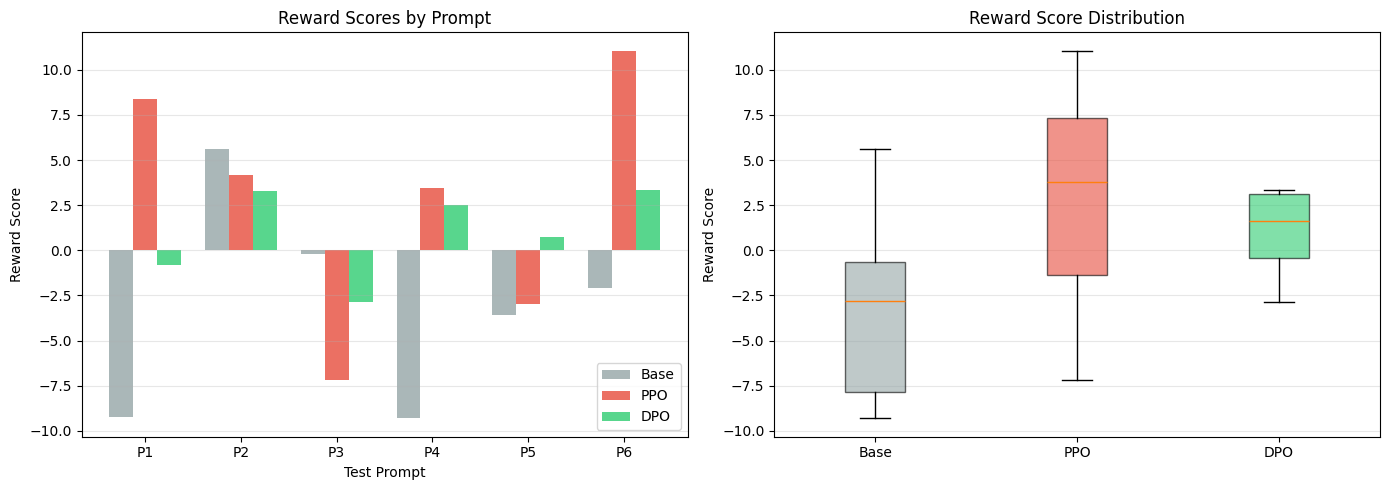

In [19]:
# Plot reward score comparison
if reward_model_available:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart: per-prompt comparison
    x = np.arange(len(test_prompts))
    width = 0.25
    short_labels = [p[:30] + "..." for p in test_prompts]

    axes[0].bar(x - width, reward_scores["base"], width, label="Base", color="#95a5a6", alpha=0.8)
    if ppo_responses[0] != "[PPO model not available]":
        axes[0].bar(x, reward_scores["ppo"], width, label="PPO", color="#e74c3c", alpha=0.8)
    axes[0].bar(x + width, reward_scores["dpo"], width, label="DPO", color="#2ecc71", alpha=0.8)

    axes[0].set_xlabel("Test Prompt")
    axes[0].set_ylabel("Reward Score")
    axes[0].set_title("Reward Scores by Prompt")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f"P{i+1}" for i in range(len(test_prompts))])
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis="y")

    # Box plot: overall distribution
    data_to_plot = [reward_scores["base"], reward_scores["dpo"]]
    labels_to_plot = ["Base", "DPO"]
    colors_to_plot = ["#95a5a6", "#2ecc71"]

    if ppo_responses[0] != "[PPO model not available]":
        data_to_plot.insert(1, reward_scores["ppo"])
        labels_to_plot.insert(1, "PPO")
        colors_to_plot.insert(1, "#e74c3c")

    bp = axes[1].boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)
    for patch, color in zip(bp["boxes"], colors_to_plot):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    axes[1].set_ylabel("Reward Score")
    axes[1].set_title("Reward Score Distribution")
    axes[1].grid(True, alpha=0.3, axis="y")

    # Print summary statistics
    print("\nReward Score Summary:")
    print(f"  Base - Mean: {np.mean(reward_scores['base']):.3f}, Std: {np.std(reward_scores['base']):.3f}")
    if ppo_responses[0] != "[PPO model not available]":
        print(f"  PPO  - Mean: {np.mean(reward_scores['ppo']):.3f}, Std: {np.std(reward_scores['ppo']):.3f}")
    print(f"  DPO  - Mean: {np.mean(reward_scores['dpo']):.3f}, Std: {np.std(reward_scores['dpo']):.3f}")

    plt.tight_layout()
    plt.savefig("./results/dpo/reward_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Reward model not available. Skipping reward score comparison.")
    print("Run Notebook 04 to train the reward model for quantitative evaluation.")

## Save DPO Adapter

In [20]:
# Adapter and tokenizer were already saved at the end of the training cell
import os
print("DPO adapter and tokenizer saved to ./results/dpo/final")
print(f"  Files: {os.listdir('./results/dpo/final')}")
print("\nTo load this model later:")
print("  from peft import PeftModel")
print("  model = AutoModelForCausalLM.from_pretrained('Qwen/Qwen2.5-7B-Instruct', ...)")
print("  model = PeftModel.from_pretrained(model, './results/dpo/final')")

DPO adapter and tokenizer saved to ./results/dpo/final
  Files: ['training_args.bin', 'adapter_model.safetensors', 'chat_template.jinja', 'tokenizer.json', 'adapter_config.json', 'ref', 'README.md', 'tokenizer_config.json']

To load this model later:
  from peft import PeftModel
  model = AutoModelForCausalLM.from_pretrained('Qwen/Qwen2.5-7B-Instruct', ...)
  model = PeftModel.from_pretrained(model, './results/dpo/final')


## Summary & Next Steps

### What We Did

In this notebook, we trained Qwen2.5-7B-Instruct using **Direct Preference Optimization (DPO)** on the UltraFeedback dataset. DPO eliminates the need for a separate reward model by directly optimizing a policy on preference pairs using a clever reparameterization of the RLHF objective.

### Key Takeaways

1. **DPO is simpler than PPO**: No reward model, no RL infrastructure, no value head — just a modified supervised learning loss on preference pairs.

2. **Same theoretical optimum**: DPO and RLHF-with-PPO converge to the same optimal policy under the Bradley-Terry preference model. The difference is purely in the optimization path.

3. **Beta controls the trade-off**: The $\beta$ parameter determines how aggressively the model departs from the reference. Lower $\beta$ = stronger preference optimization, higher $\beta$ = more conservative.

4. **Practical trade-offs vs PPO**:
   - DPO is easier to implement and more stable
   - PPO can adapt to distributional shift through online sampling
   - DPO relies on the quality and coverage of the static preference dataset
   - PPO can potentially achieve better results with careful tuning, but DPO is more robust to hyperparameter choices

### DPO vs PPO: When to Use Which?

| Use DPO when... | Use PPO when... |
|-----------------|------------------|
| You have good preference data | You need online exploration |
| Simplicity and stability matter | You have compute budget for RL |
| Limited engineering resources | Fine-grained reward shaping is needed |
| Quick iteration is important | Maximum performance is the goal |

### Next Steps: Notebook 07 — Comprehensive Evaluation

In the final notebook, we will bring together all the models from this series — base, SFT, reward model, PPO, and DPO — and conduct a thorough evaluation. We will assess:
- Generation quality across diverse prompts
- Safety and refusal behavior
- Reward model scores
- Human preference alignment
- The full alignment pipeline from start to finish